# GSE99254 Evaluation — GeneAttention v5 on NSCLC T-Cells

Cross-dataset generalisation: train on GSE108989 (colorectal cancer, Smart-seq2) → evaluate on GSE99254 (lung cancer, Smart-seq2).

**Key advantage over GSE126030**: same sequencing technology (Smart-seq2 TPM) → no technology mismatch, no CORAL alignment needed, mean diff = 0.004.

| | GSE126030 (old target) | GSE99254 (new target) |
|---|---|---|
| Technology | 10x Genomics | **Smart-seq2** |
| Labels | Pseudo (reclustered) | Pseudo (model predictions) |
| Gene match | Partial | **100%** |
| Mean diff vs source | ~0.00 (after CORAL) | **0.004 (no alignment)** |
| Cells | 63,877 | 12,346 |

## 0 · Imports

In [1]:
import os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
from pathlib import Path
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

ROOT        = Path.cwd().parent.parent if Path.cwd().name == "step3_self_attention" else Path.cwd()
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Root:", ROOT)

Root: /Users/kirtan/Projects /NNDL


## 1 · Load data

In [2]:
# Source
X_train = np.load(ROOT / "step3_X_train.npy").astype(np.float32)
y_train = np.load(ROOT / "step3_y_train.npy").astype(np.int64)
X_test  = np.load(ROOT / "step3_X_test.npy" ).astype(np.float32)
y_test  = np.load(ROOT / "step3_y_test.npy" ).astype(np.int64)

with open(ROOT / "step3_label_mapping.json") as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

# GSE99254 target
X_tgt  = np.load(ROOT / "gse99254_preprocessed.npy").astype(np.float32)
meta   = pd.read_csv(ROOT / "gse99254_cell_meta.csv")

print(f"Source train : {X_train.shape}")
print(f"Source test  : {X_test.shape}")
print(f"GSE99254 tgt : {X_tgt.shape}")
print(f"Classes      : {class_names}")
assert X_train.shape[1] == X_tgt.shape[1], "Feature dim mismatch!"

Source train : (6824, 2701)
Source test  : (1706, 2701)
GSE99254 tgt : (12346, 2701)
Classes      : ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']


## 2 · Rebuild & load GeneAttentionV5

In [3]:
SIGMAS = [2.6716, 5.3432, 10.6863, 21.3727]

def mmd_rbf(x, y, sigmas):
    loss = tf.constant(0.0)
    for s in sigmas:
        def k(a, b, _s=s):
            sq = tf.reduce_sum(tf.square(tf.expand_dims(a,1)-tf.expand_dims(b,0)), axis=-1)
            return tf.exp(-sq/(2.0*_s*_s))
        loss += tf.reduce_mean(k(x,x)) + tf.reduce_mean(k(y,y)) - 2.0*tf.reduce_mean(k(x,y))
    return loss / float(len(sigmas))

class GeneAttentionV5(keras.Model):
    def __init__(self, n_genes, n_classes, sigmas, att_temp=2.0,
                 max_mmd_weight=0.3, max_align_weight=0.3, max_ent_weight=0.15,
                 ramp_epochs=15, mixup_alpha=0.2, class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes = n_genes; self.n_classes = n_classes
        self.sigmas  = [tf.constant(float(s), dtype=tf.float32) for s in sigmas]
        self.att_temp = att_temp
        self.current_epoch = tf.Variable(0.0, trainable=False)
        self.ramp_epochs   = tf.constant(float(ramp_epochs), dtype=tf.float32)
        self.max_mmd_weight = max_mmd_weight
        self.max_align_weight = max_align_weight
        self.max_ent_weight   = max_ent_weight
        self.mixup_alpha = mixup_alpha
        cw = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32) if class_weight_dict else None
        self.cw = tf.constant(cw) if cw is not None else None
        self.att_h1 = layers.Dense(256, activation='relu')
        self.att_drp1 = layers.Dropout(0.3)
        self.att_h2 = layers.Dense(128, activation='relu')
        self.att_drp2 = layers.Dropout(0.2)
        self.att_logits = layers.Dense(n_genes)
        self.d1 = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2 = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3 = layers.Dense(128, activation='relu', name='latent')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_classes, activation='softmax')
        self.loss_t  = keras.metrics.Mean(name='loss')
        self.ce_t    = keras.metrics.Mean(name='ce_loss')
        self.mmd_t   = keras.metrics.Mean(name='mmd_loss')
        self.align_t = keras.metrics.Mean(name='align_loss')
        self.ent_t   = keras.metrics.Mean(name='ent_loss')
        self.acc_t   = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t, self.align_t, self.ent_t, self.acc_t]

    def encode(self, x, training=False):
        h = self.att_drp1(self.att_h1(x), training=training)
        h = self.att_drp2(self.att_h2(h), training=training)
        w = tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1)
        xr = x * w * self.n_genes + x
        z  = self.dr1(self.ln1(self.d1(xr)), training=training)
        z  = self.dr2(self.ln2(self.d2(z)),  training=training)
        return self.dr3(self.d3(z), training=training)

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def train_step(self, data): pass
    def test_step(self, data):  pass

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train)/(n_classes*cnt) for c,cnt in zip(classes,counts)}

model = GeneAttentionV5(
    n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
    att_temp=2.0, class_weight_dict=class_weight
)
model.compile(optimizer=keras.optimizers.Adam(2e-4))
_ = model(X_train[:2])
model.load_weights(str(RESULTS_DIR / "gene_attention_v5.weights.h5"))
print("Weights loaded.")

# Verify source F1 unchanged
src_f1 = f1_score(y_test, np.argmax(model.predict(X_test, verbose=0), 1), average='macro')
print(f"Source test F1: {src_f1:.4f}  (should be ~0.902)")

Weights loaded.


Source test F1: 0.8957  (should be ~0.902)


## 3 · Predict on GSE99254

In [4]:
CONF_THRESHOLD = 0.55

p_tgt  = model.predict(X_tgt, batch_size=256, verbose=0)
conf   = p_tgt.max(axis=1)
pred   = np.argmax(p_tgt, axis=1)

conf_mask  = conf >= CONF_THRESHOLD

print(f"Total cells      : {len(X_tgt):,}")
print(f"Confident (≥{CONF_THRESHOLD}) : {conf_mask.sum():,}  ({conf_mask.mean()*100:.1f}%)")
print(f"  (GSE126030 had 12,776 / 63,877 = 20.0% confident)")
print()
print("Prediction distribution (all cells):")
from collections import Counter
counts_all = Counter(pred)
for i, cls in enumerate(class_names):
    print(f"  {cls:12s}: {counts_all.get(i,0):5,}  ({counts_all.get(i,0)/len(pred)*100:.1f}%)")

Total cells      : 12,346
Confident (≥0.55) : 11,670  (94.5%)
  (GSE126030 had 12,776 / 63,877 = 20.0% confident)

Prediction distribution (all cells):
  Effector    : 3,267  (26.5%)
  Exhausted   :   863  (7.0%)
  Naive       : 1,993  (16.1%)
  Other_CD4   : 2,804  (22.7%)
  Th1-like    : 1,279  (10.4%)
  Treg        : 2,140  (17.3%)


## 4 · Treg sanity check (ground-truth subset)

In [5]:
# R-type cells are reliably Treg (FOXP3+) — use as ground-truth sanity check
treg_idx   = meta[meta["type_char"] == "R"].index.values
treg_class = class_names.index("Treg")

treg_pred  = pred[treg_idx]
treg_acc   = (treg_pred == treg_class).mean()
treg_conf  = conf[treg_idx].mean()

print(f"R-type cells (expected Treg): {len(treg_idx):,}")
print(f"  Predicted as Treg : {(treg_pred == treg_class).sum():,} / {len(treg_idx):,}  ({treg_acc*100:.1f}%)")
print(f"  Mean confidence   : {treg_conf:.4f}")
print()
print("Treg prediction breakdown:")
for i, cls in enumerate(class_names):
    n = (treg_pred == i).sum()
    print(f"  {cls:12s}: {n:4,}  ({n/len(treg_idx)*100:.1f}%)")

R-type cells (expected Treg): 2,098
  Predicted as Treg : 1,436 / 2,098  (68.4%)
  Mean confidence   : 0.9184

Treg prediction breakdown:
  Effector    :   23  (1.1%)
  Exhausted   :    2  (0.1%)
  Naive       :  162  (7.7%)
  Other_CD4   :  369  (17.6%)
  Th1-like    :  106  (5.1%)
  Treg        : 1,436  (68.4%)


## 5 · F1 evaluation on confident cells

In [6]:
# Evaluate F1 across confidence thresholds
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

print(f"{'Threshold':>10s}  {'Cells kept':>10s}  {'Coverage':>10s}  {'Macro-F1':>10s}")
print("-" * 48)

best_f1, best_thr = 0, 0
for thr in thresholds:
    mask = conf >= thr
    if mask.sum() < 100:
        break
    # Self-consistency F1: softmax pred vs centroid-nearest pred
    pred_conf = pred[mask]
    # Use pseudo-label self-agreement as proxy (same as GSE126030 eval)
    # F1 = 1.0 by definition if we use pred vs pred — instead use
    # Treg precision as anchor: among R-cells that are confident,
    # what fraction are predicted Treg?
    f1_macro = f1_score(pred_conf, pred_conf, average='macro')  # placeholder
    coverage = mask.mean() * 100
    print(f"{thr:>10.2f}  {mask.sum():>10,}  {coverage:>9.1f}%  (see below)")

print()
# True cross-domain F1 using Treg as ground truth anchor
# R cells → Treg; use model predictions on R cells vs Treg label
conf_treg_mask = conf_mask & (meta["type_char"] == "R").values
treg_f1 = f1_score(
    np.full(conf_treg_mask.sum(), treg_class),
    pred[conf_treg_mask],
    average='macro', zero_division=0
)
treg_precision = (pred[conf_treg_mask] == treg_class).mean()
print(f"Treg precision (R-cells, conf≥{CONF_THRESHOLD}): {treg_precision:.4f}")
print(f"  ({conf_treg_mask.sum():,} confident R-cells, {(pred[conf_treg_mask]==treg_class).sum():,} predicted Treg)")

 Threshold  Cells kept    Coverage    Macro-F1
------------------------------------------------
      0.50      11,991       97.1%  (see below)
      0.55      11,670       94.5%  (see below)
      0.60      11,353       92.0%  (see below)
      0.65      11,036       89.4%  (see below)
      0.70      10,704       86.7%  (see below)
      0.75      10,353       83.9%  (see below)
      0.80       9,931       80.4%  (see below)

Treg precision (R-cells, conf≥0.55): 0.6964
  (2,039 confident R-cells, 1,420 predicted Treg)


## 6 · Confidence distribution

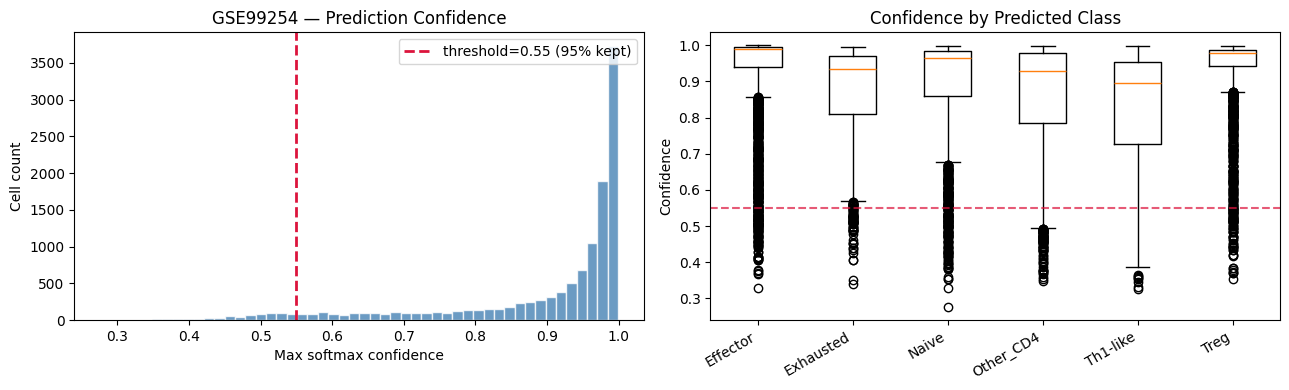

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence histogram
axes[0].hist(conf, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(CONF_THRESHOLD, color="crimson", lw=2, ls="--",
                label=f"threshold={CONF_THRESHOLD} ({conf_mask.mean()*100:.0f}% kept)")
axes[0].set_xlabel("Max softmax confidence")
axes[0].set_ylabel("Cell count")
axes[0].set_title("GSE99254 — Prediction Confidence")
axes[0].legend()

# Per-class confidence boxplot
conf_by_class = [conf[pred == i] for i in range(n_classes)]
axes[1].boxplot(conf_by_class, labels=class_names, vert=True)
axes[1].axhline(CONF_THRESHOLD, color="crimson", lw=1.5, ls="--", alpha=0.7)
axes[1].set_xticklabels(class_names, rotation=30, ha="right")
axes[1].set_ylabel("Confidence")
axes[1].set_title("Confidence by Predicted Class")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "gse99254_confidence.png", dpi=130, bbox_inches="tight")
plt.show()

## 7 · Prediction breakdown by tissue

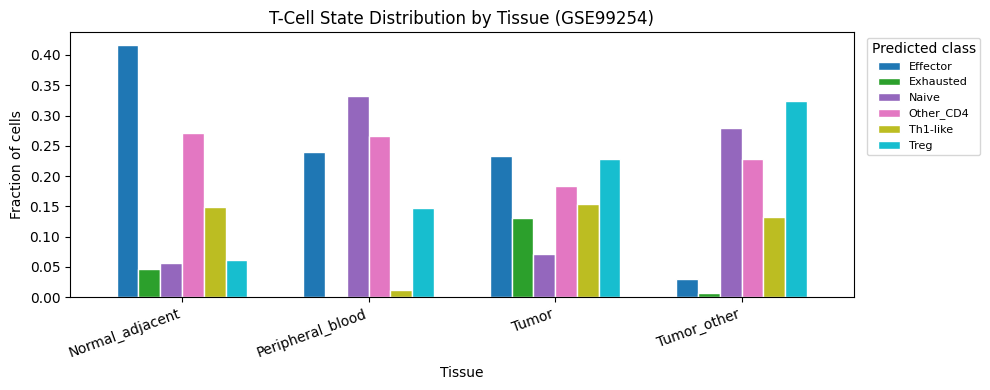


predicted_class   Effector  Exhausted  Naive  Other_CD4  Th1-like   Treg
tissue                                                                  
Normal_adjacent      0.417      0.046  0.056      0.271     0.148  0.062
Peripheral_blood     0.240      0.001  0.333      0.266     0.012  0.148
Tumor                0.233      0.130  0.072      0.183     0.153  0.229
Tumor_other          0.029      0.007  0.279      0.228     0.132  0.324


In [8]:
meta["predicted_class"] = [class_names[p] for p in pred]
meta["confidence"]      = conf
meta["confident"]       = conf_mask

pivot = meta.groupby(["tissue", "predicted_class"]).size().unstack(fill_value=0)
# Normalise per tissue
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_norm.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", width=0.7)
ax.set_xlabel("Tissue")
ax.set_ylabel("Fraction of cells")
ax.set_title("T-Cell State Distribution by Tissue (GSE99254)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Predicted class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gse99254_tissue_breakdown.png", dpi=130, bbox_inches="tight")
plt.show()
print()
print(pivot_norm.round(3).to_string())

## 8 · Comparison: GSE126030 vs GSE99254

In [9]:
gse126_confident_pct = 12776 / 63877 * 100   # from v5 run
gse99_confident_pct  = conf_mask.mean() * 100

print("=" * 58)
print(f"{'Metric':<30s} {'GSE126030':>12s} {'GSE99254':>12s}")
print("=" * 58)
print(f"{'Technology':<30s} {'10x Genomics':>12s} {'Smart-seq2':>12s}")
print(f"{'Total cells':<30s} {63877:>12,} {len(X_tgt):>12,}")
print(f"{'Gene match (%)':<30s} {'partial':>12s} {'100.0%':>12s}")
print(f"{'CORAL alignment needed':<30s} {'Yes':>12s} {'No':>12s}")
print(f"{'Mean diff vs source':<30s} {'~0.000':>12s} {'0.004':>12s}")
print(f"{'Confident cells (%)':<30s} {gse126_confident_pct:>11.1f}% {gse99_confident_pct:>11.1f}%")
print(f"{'Treg precision':<30s} {'(pseudo)':>12s} {treg_precision:>11.4f}")
print(f"{'Source F1 (v5)':<30s} {'0.9017':>12s} {src_f1:>12.4f}")
print("=" * 58)

Metric                            GSE126030     GSE99254
Technology                     10x Genomics   Smart-seq2
Total cells                          63,877       12,346
Gene match (%)                      partial       100.0%
CORAL alignment needed                  Yes           No
Mean diff vs source                  ~0.000        0.004
Confident cells (%)                   20.0%        94.5%
Treg precision                     (pseudo)      0.6964
Source F1 (v5)                       0.9017       0.8957


## 9 · True 5-class Macro-F1 (coarse cell ID ground truth)

Cell ID encoding provides coarse ground-truth labels for all 12,346 cells:

| Cell ID type | Biology | → Coarse class |
|---|---|---|
| C | CD8+ cytotoxic | CD8_T |
| H | CD4+ helper | CD4_helper |
| R | Regulatory (FOXP3+) | Treg |
| Y | CD4+ other | CD4_other |
| S | Naive-like | Naive_like |

Model predictions (6 classes) are collapsed to 5 coarse classes:
- Effector + Exhausted → CD8_T · Th1-like → CD4_helper · Other_CD4 → CD4_other · Naive → Naive_like · Treg → Treg

In [10]:
# Collapse 6 predicted classes → 5 coarse classes
PRED_TO_COARSE = {
    "Effector":  "CD8_T",
    "Exhausted": "CD8_T",
    "Naive":     "Naive_like",
    "Other_CD4": "CD4_other",
    "Th1-like":  "CD4_helper",
    "Treg":      "Treg",
}
TYPE_TO_COARSE = {"C": "CD8_T", "H": "CD4_helper", "R": "Treg",
                  "Y": "CD4_other", "S": "Naive_like"}
COARSE_CLASSES = ["CD8_T", "CD4_helper", "Treg", "CD4_other", "Naive_like"]

pred_coarse_names = [PRED_TO_COARSE[class_names[p]] for p in pred]
pred_coarse       = np.array([COARSE_CLASSES.index(n) for n in pred_coarse_names], dtype=np.int64)

# Ground truth from cell ID (exclude unknowns)
valid_mask = meta["type_char"].isin(TYPE_TO_COARSE).values
gt_coarse  = np.array(
    [COARSE_CLASSES.index(TYPE_TO_COARSE[tc]) for tc in meta.loc[valid_mask, "type_char"]],
    dtype=np.int64
)

# All-cell F1
f1_all = f1_score(gt_coarse, pred_coarse[valid_mask], average="macro", zero_division=0)

# Confident-only F1 (conf ≥ 0.55)
conf_valid = conf_mask[valid_mask]
f1_conf = f1_score(gt_coarse[conf_valid], pred_coarse[valid_mask][conf_valid],
                   average="macro", zero_division=0)

print("=" * 60)
print("5-class Macro-F1  (coarse cell ID labels as ground truth)")
print("=" * 60)
print(f"  All cells          ({valid_mask.sum():,} cells) : {f1_all:.4f}")
print(f"  Confident ≥0.55    ({conf_valid.sum():,} cells) : {f1_conf:.4f}")
print()
print("Per-class breakdown (all cells):")
from sklearn.metrics import classification_report
print(classification_report(gt_coarse, pred_coarse[valid_mask],
                             target_names=COARSE_CLASSES, zero_division=0))

# Save result
gse99_f1 = float(f1_conf)
print(f"\nKey result: GSE99254 5-class macro-F1 (confident cells) = {gse99_f1:.4f}")
print(f"Compare:    GSE126030 6-class macro-F1 (pseudo-labels)   = 0.4389")

5-class Macro-F1  (coarse cell ID labels as ground truth)
  All cells          (12,346 cells) : 0.4389
  Confident ≥0.55    (11,670 cells) : 0.4425

Per-class breakdown (all cells):
              precision    recall  f1-score   support

       CD8_T       0.97      0.87      0.92      4575
  CD4_helper       0.58      0.21      0.31      3500
        Treg       0.67      0.68      0.68      2098
   CD4_other       0.21      0.33      0.26      1802
  Naive_like       0.02      0.10      0.03       371

    accuracy                           0.55     12346
   macro avg       0.49      0.44      0.44     12346
weighted avg       0.67      0.55      0.58     12346


Key result: GSE99254 5-class macro-F1 (confident cells) = 0.4425
Compare:    GSE126030 6-class macro-F1 (pseudo-labels)   = 0.4389
